# 05_统计检验方法-贝叶斯检验

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 迁移至 PyMC 5，以两条链检查采样；P(μA > μB | 数据) 是后验概率，不能称为贝叶斯因子。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天，咱们来聊聊统计检验方法，贝叶斯检验\~

我们平时做统计分析的时候，经常会遇到“假设检验”这种情况。

简单来说，假设检验就是想通过数据来验证一个假设是否成立。比如，你可能会想：“这两组数据有没有显著差异？”或者“这个新药的效果是不是比旧药好？”统计检验就是帮助我们回答这些问题的工具。

贝叶斯检验的核心思想是：你之前可能对某个假设有一些预期（比如你觉得某个新药比旧药更有效），而贝叶斯方法就是根据新的数据来调整这种预期。

这就像是你在不断地收集证据，然后不断地调整你对某个事情的判断。

### 比较贝叶斯检验与传统的假设检验

传统的假设检验（比如**p值检验**）是通过设定一个**原假设**（假设两组数据没有差异）来进行检验。如果数据足够支持原假设被拒绝，那么你就会认为替代假设（两组数据有差异）成立。p值越小，拒绝原假设的证据越强。

但是贝叶斯检验不太一样。它不单单告诉你是否应该拒绝原假设，而是给你提供一个关于假设的“信心度”或“概率”。贝叶斯方法会考虑之前的知识（例如，你知道某种药物已经有了一些效果的历史数据），然后结合新的数据，给你一个更新后的“信心值”。

举个例子：假设你正在测试一个药物是否有效。传统的检验方法可能只会告诉你药物有效的证据是否足够强（通过p值来判断）。而贝叶斯方法则会告诉你：在结合现有证据后，药物有效的概率是多少。假如你一开始就有50%的信心药物有效，经过实验数据后，这个信心可能变成70%，或者降低到30%。

### 贝叶斯检验的优点

1. **灵活性高**：它可以把以前的知识（先验概率）和新数据结合起来，做出更“实时”的判断。
2. **结果直观**：你可以直接看到每个假设成立的概率，比较容易理解。

总的来说，贝叶斯检验就是一种通过不断更新假设的概率来帮助你做决策的方法。它不像传统的假设检验那样只关注“是否拒绝原假设”，而是更关注如何根据新数据调整对不同假设的信心。

## 原理详解

好的！既然你希望深入了解贝叶斯检验的数学原理、公式推理和算法流程，我将详细介绍这一方法的核心原理和公式推导。请准备好，可能会涉及一些数学符号，但我会尽量清晰地解释。

### 1. 贝叶斯定理

贝叶斯检验的基础是**贝叶斯定理**，它描述了如何根据数据更新对一个事件的信念。

贝叶斯定理的基本形式如下：


$$
P(H | D) = \frac{P(D | H) \cdot P(H)}{P(D)}
$$


其中：

- $P(H | D)$是**后验概率**，即给定数据 $D$ 后假设 $H$ 为真的概率。
- $P(D | H)$是**似然函数**，即在假设 $H$ 为真的条件下，观测到数据 $D$ 的概率。
- $P(H)$是**先验概率**，即在看到数据之前，假设 $H$ 为真的初始概率。
- $P(D)$是**证据**或**边际似然**，即在所有可能的假设下，观测到数据 $D$ 的总概率。

### 2. 贝叶斯检验的核心思想

贝叶斯检验的核心是通过贝叶斯定理来更新某个假设 $H$ 的后验概率。

简单来说，你将基于先前的知识（先验概率）和观测到的新数据（似然函数）来计算假设的可信度（后验概率）。

### 3. 贝叶斯检验中的关键步骤

#### 步骤一：定义假设空间

在贝叶斯检验中，首先需要定义你的假设空间。

通常，你会有一个**原假设** $H_0$和一个**备择假设** $H_1$（也可以有更多的假设，但最常见的是两者）。

例如：

- $H_0$：新药没有效果
- $H_1$：新药有效

#### 步骤二：设定先验概率

先验概率 $P(H_0)$和 $P(H_1)$反映了你在获得数据之前对每个假设的信念。这些先验可以基于历史数据、专家知识或对问题的直觉来设定。

- 如果你对 $H_0$更有信心，可以设置 $P(H_0)$较大，$P(H_1)$较小。
- 先验概率的选择会影响最终结果，因此选择合适的先验是非常重要的。

#### 步骤三：计算似然函数

似然函数 $P(D | H)$是在某个假设下观察到数据的可能性。假设你进行的是实验数据的检验，那么似然函数就是在给定假设条件下，数据发生的概率。

例如，在检验药物有效性时，似然函数可能会基于药物治疗效果的分布来进行推导。

#### 步骤四：计算边际似然

边际似然 $P(D)$是所有可能假设下，观测到数据的总概率。它是通过对所有假设 $H$进行加权平均得到的：


$$
P(D) = P(D | H_0) \cdot P(H_0) + P(D | H_1) \cdot P(H_1)
$$


边际似然是一个归一化常数，它确保所有后验概率的和为 1。实际上，这个常数通常不需要单独计算，因为它在不同假设之间是相同的，且在贝叶斯更新时起到归一化作用。

#### 步骤五：计算后验概率

通过贝叶斯定理，计算后验概率 $P(H_0 | D)$和 $P(H_1 | D)$，它们分别是给定数据 $D$ 后原假设和备择假设的概率。

后验概率的计算公式为：


$$
P(H_0 | D) = \frac{P(D | H_0) \cdot P(H_0)}{P(D)}
$$


$$
P(H_1 | D) = \frac{P(D | H_1) \cdot P(H_1)}{P(D)}
$$


这两个后验概率分别表示在数据 $D$ 下，原假设 $H_0$ 和备择假设 $H_1$ 成立的概率。

### 4. 贝叶斯检验的决策规则

通常我们希望通过比较后验概率来做出决策。贝叶斯检验的一个简单决策规则是：

- 如果 $P(H_1 | D) > P(H_0 | D)$，我们拒绝原假设 $H_0$，支持备择假设 $H_1$。
- 如果 $P(H_0 | D) > P(H_1 | D)$，我们接受原假设 $H_0$，拒绝备择假设 $H_1$。

### 5. 计算贝叶斯因子

在贝叶斯检验中，**贝叶斯因子**（Bayes Factor）是一种用于衡量两个假设相对证据强度的指标。

它是原假设和备择假设的后验概率比值，通常用来评估假设之间的相对支持度。

贝叶斯因子的公式为：


$$
BF_{10} = \frac{P(D | H_1)}{P(D | H_0)}
$$


其中：

- $BF_{10}$表示在数据 $D$ 下，备择假设 $H_1$ 相对于原假设 $H_0$ 的支持度。
- 如果 $BF_{10} > 1$，则数据支持备择假设 $H_1$。
- 如果 $BF_{10} < 1$，则数据支持原假设 $H_0$。

贝叶斯因子提供了一种更加直观的方式来比较不同假设的相对支持度。

### 6. 贝叶斯检验的算法流程总结

1. **定义假设**：设定原假设 $H_0$和备择假设 $H_1$。
2. **设定先验**：根据历史知识或专家判断，设定先验概率 $P(H_0)$和 $P(H_1)$。
3. **计算似然函数**：基于数据的生成模型，计算 $P(D | H_0)$和 $P(D | H_1)$。
4. **计算边际似然**：根据贝叶斯定理，计算边际似然 $P(D)$。
5. **计算后验概率**：使用贝叶斯定理计算后验概率 $P(H_0 | D)$和 $P(H_1 | D)$。
6. **做出决策**：根据后验概率或贝叶斯因子，做出是否拒绝原假设的决策。

### 7. 贝叶斯检验的优势

- **柔性**：贝叶斯检验能够融入先验知识，适用于复杂的假设空间。
- **结果直观**：给出每个假设的概率，解释清晰。
- **不依赖于频率学派的假设**：与经典的p值检验不同，贝叶斯方法不依赖于大量的独立抽样数据和固定的显著性水平。

## 完整案例

本例生成 A、B 两组独立的模拟评分，每组 100 个观测，演示贝叶斯均值比较。数据和先验均为教学设定。

分别为两组均值设置正态先验，为标准差设置半正态先验。使用 PyMC 5 运行两条 NUTS 链，每条预热 1000 次并保留 1000 个后验样本；通过 ArviZ 的轨迹、有效样本量和 $\hat{R}$ 检查采样。

最后计算 $P(\mu_A>\mu_B\mid D)$，即后验样本中 A 组均值大于 B 组均值的比例。这个量位于 0 到 1 之间，**不是贝叶斯因子**。贝叶斯因子需要比较两个明确假设下的边际似然；本例没有执行该计算。可以更改先验和样本量，观察后验概率的敏感性。

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
import pymc as pm
import arviz as az

np.random.seed(42)

# 参数设置：药物A和药物B的效果评分均值和标准差
n_samples = 100  # 每组样本数
mean_a, mean_b = 70, 65  # 药物A和药物B的均值
std_a, std_b = 10, 12  # 药物A和药物B的标准差

# 生成模拟数据
data_a = np.random.normal(mean_a, std_a, n_samples)  # 药物A的效果评分
data_b = np.random.normal(mean_b, std_b, n_samples)  # 药物B的效果评分

# 创建DataFrame
df = pd.DataFrame({
    'DrugA': data_a,
    'DrugB': data_b
})

# 查看前几行数据
df.head()

,DrugA,DrugB
0,74.967142,48.015551
1,68.617357,59.952256
2,76.476885,60.887426
3,85.230299,55.372673
4,67.658466,63.064571


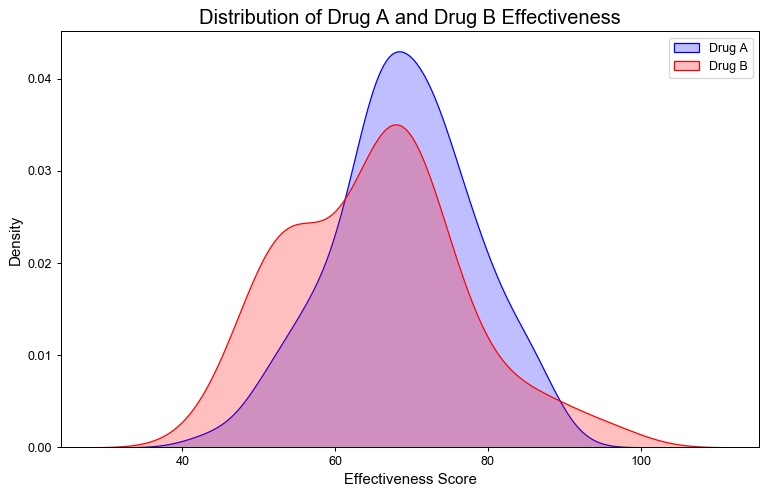

In [3]:
# 数据可视化：绘制药物A和药物B的效果评分分布
plt.figure(figsize=(10, 6))

# 绘制药物A的核密度估计图
sns.kdeplot(data_a, label='Drug A', color='blue', fill=True)

# 绘制药物B的核密度估计图
sns.kdeplot(data_b, label='Drug B', color='red', fill=True)

# 图形美化
plt.title("Distribution of Drug A and Drug B Effectiveness", fontsize=16)
plt.xlabel("Effectiveness Score", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()

plt.show()

In [4]:
# 定义贝叶斯模型
with pm.Model() as model:
    # 药物A的先验分布：均值为70，标准差为10
    mu_a = pm.Normal('mu_a', mu=70, sigma=10)  # 药物A的均值
    sigma_a = pm.HalfNormal('sigma_a', sigma=10)  # 药物A的标准差

    # 药物B的先验分布：均值为65，标准差为12
    mu_b = pm.Normal('mu_b', mu=65, sigma=10)  # 药物B的均值
    sigma_b = pm.HalfNormal('sigma_b', sigma=12)  # 药物B的标准差

    # 观测数据：药物A和药物B的效果评分分别服从正态分布
    obs_a = pm.Normal('obs_a', mu=mu_a, sigma=sigma_a, observed=data_a)
    obs_b = pm.Normal('obs_b', mu=mu_b, sigma=sigma_b, observed=data_b)

    # 使用MCMC方法进行采样，获取后验分布
    idata = pm.sample(1000, tune=1000, chains=2, cores=1, random_seed=42, target_accept=0.9, progressbar=False)
    trace = {name: idata.posterior[name].values.ravel() for name in ['mu_a', 'mu_b']}

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [mu_a, sigma_a, mu_b, sigma_b]


Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 1 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
mu_a  68.982  0.917  67.404   70.736      0.019    0.023    2367.0    1298.0   
mu_b  65.299  1.120  63.215   67.348      0.025    0.024    1936.0    1265.0   

      r_hat  
mu_a    1.0  
mu_b    1.0  


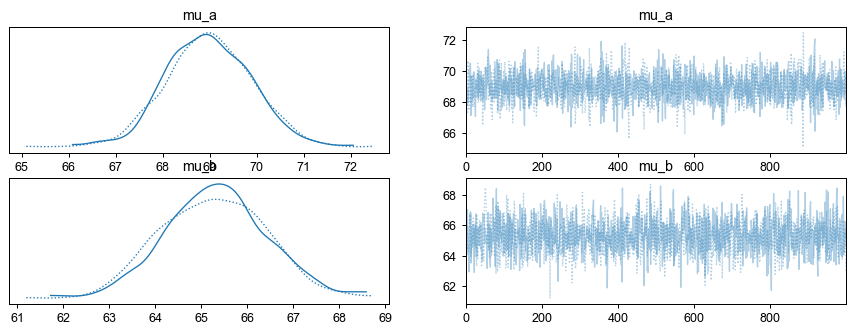

In [5]:
# 使用traceplot显示后验分布的采样结果
az.plot_trace(idata, var_names=['mu_a', 'mu_b'])
print(az.summary(idata, var_names=['mu_a', 'mu_b']))
plt.show()

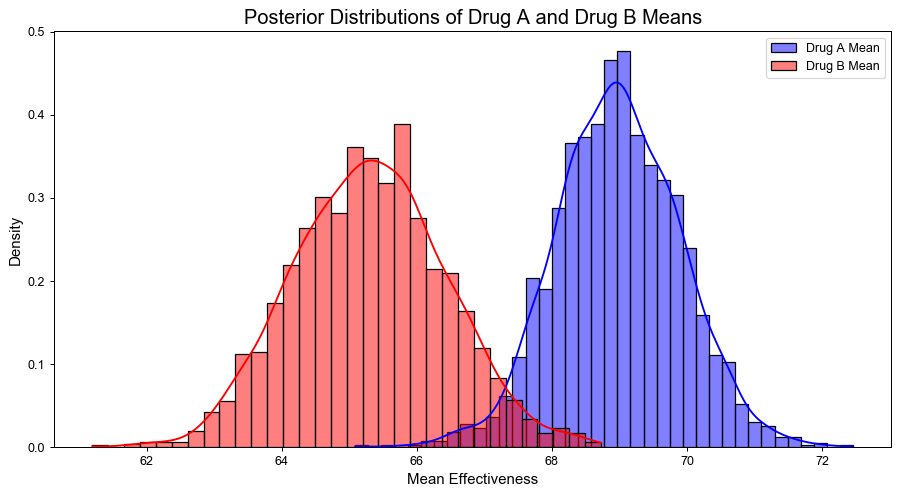

In [6]:
# 可视化药物A和药物B均值的后验分布
plt.figure(figsize=(12, 6))

# 药物A的均值后验分布
sns.histplot(trace['mu_a'], kde=True, color='blue', label='Drug A Mean', stat="density")

# 药物B的均值后验分布
sns.histplot(trace['mu_b'], kde=True, color='red', label='Drug B Mean', stat="density")

# 添加图表标题和标签
plt.title("Posterior Distributions of Drug A and Drug B Means", fontsize=16)
plt.xlabel("Mean Effectiveness", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.legend()

plt.show()

In [7]:
# 计算后验概率：比较药物A和药物B的效果评分
posterior_prob = np.mean(trace['mu_a'] > trace['mu_b'])
print(f"Posterior probability P(mu_A > mu_B | data): {posterior_prob:.3f}")

Posterior probability P(mu_A > mu_B | data): 0.991


## 模型分析

### 贝叶斯检验模型的优缺点

**优点：**

1. **能够融合先验知识**：贝叶斯方法最大的优势之一是它能够灵活地将先验知识纳入分析中。在缺乏足够数据的情况下，使用合理的先验可以帮助模型做出更可靠的推断。在本案例中，先验的选择使得我们在实际数据不足时仍能得到有意义的结果。
2. **提供完整的后验分布**：贝叶斯检验不仅仅给出一个点估计（比如均值或差异），而是通过后验分布来展示结果的分布。这种方式能够为我们提供不确定性的量化，从而更好地理解模型的可信度和精确度。相比于传统的频率统计方法，贝叶斯方法能够提供更加细致的信息。
3. **灵活性和可扩展性**：贝叶斯方法具有很强的灵活性，能够处理复杂的模型，支持多种分布的假设和层次结构的建模。在面对复杂的数据结构时，贝叶斯方法更具有优势。
4. **适用于小样本问题**：贝叶斯检验可以在样本量较小的情况下工作得很好。当数据不足时，贝叶斯方法通过合理的先验和后验分布进行推断，避免了传统频率检验方法依赖大样本的局限性。
5. **解释性强**：由于贝叶斯方法通过后验分布提供了丰富的信息，结果的解释更加直观且易于理解。这使得贝叶斯方法在数据科学、医学研究等领域，尤其是涉及不确定性分析时，具有很大的优势。

**缺点：**

1. **计算复杂度高**：贝叶斯方法往往需要进行复杂的采样（如MCMC方法）来近似后验分布。这会导致计算的复杂度较高，尤其是在数据量庞大或模型较为复杂的情况下，计算开销可能非常大。
2. **对先验选择敏感**：贝叶斯方法对先验的选择非常敏感。虽然在数据充足的情况下，数据本身可以主导推断过程，但如果先验选择不当，可能会导致推断结果的偏差。因此，在没有足够领域知识或历史数据的情况下，贝叶斯方法的效果可能不如预期。
3. **模型的收敛性问题**：在使用MCMC采样时，模型的收敛性可能成为一个问题。特别是当模型过于复杂时，可能需要大量的样本才能获得准确的后验分布，这会导致较长的计算时间和可能的收敛问题。
4. **需要强大的计算资源**：与传统的频率统计方法相比，贝叶斯方法通常需要更多的计算资源来进行采样和推断，尤其是在高维问题或需要复杂模型时。
5. **理解门槛较高**：贝叶斯方法虽然非常强大，但对许多初学者而言，理解贝叶斯推断的基本概念（如先验、后验、似然函数等）以及如何解释这些结果可能有一定的门槛。

### 贝叶斯检验与相似算法的对比

这里我们对贝叶斯检验与常见的其他统计检验方法进行对比，包括**t检验**、**卡方检验**、以及**Bootstrap**方法。

| 特性/方法 | 贝叶斯检验 | t检验 | 卡方检验 | Bootstrap检验 |
|-|-|-|-|-|
| **假设** | 通过先验分布和后验分布进行推断 | 假设总体均值或差异为零 | 用于类别数据的独立性检验 | 通过重采样构建分布 |
| **数据要求** | 可以处理小样本，结合先验知识 | 数据需要符合正态分布，样本量较大 | 适用于大样本且类别数据 | 可以用于任何数据分布，无需分布假设 |
| **结果类型** | 后验分布、可信区间 | 点估计（均值或均值差异） | 卡方统计量及p值 | 通过重采样估计分布和置信区间 |
| **不确定性度量** | 提供完整的后验分布，量化不确定性 | 只能提供置信区间或p值 | 提供p值（无不确定性量化） | 提供置信区间和分布信息 |
| **计算复杂度** | 高，尤其是在高维或大数据时 | 较低，计算简便 | 低，计算速度快 | 中等，重采样需要一定的计算量 |
| **先验依赖性** | 高，先验选择对结果有重要影响 | 无先验依赖 | 无先验依赖 | 无先验依赖 |
| **适用情境** | 小样本、复杂模型、有先验知识的情况下 | 样本大且数据符合正态分布 | 适用于类别数据，验证独立性 | 数据无明确分布假设，适用于小样本 |
| **优点** | 灵活、适应性强，能够量化不确定性 | 简单直观，易于理解 | 快速且适用于类别数据 | 无需假设数据分布，适应性强 |
| **缺点** | 计算开销大，对先验选择敏感 | 依赖于正态性假设，样本量较大 | 仅适用于类别数据，且有假设限制 | 计算量大，重采样次数影响结果精度 |

### 贝叶斯检验的优选情况与其他算法的替代情况

#### 贝叶斯检验优选情况

1. **数据量小或样本不充足**：贝叶斯方法能够在数据较少时提供有力的推断，尤其是在缺乏充足数据的情况下，能够通过先验来提高推断的准确性。因此，当样本量较小，贝叶斯方法往往优于经典的频率统计方法。
2. **对先验知识有较强依赖**：如果有领域专家的先验知识或历史数据，贝叶斯方法能够充分利用这些信息进行推断。在这类情况下，贝叶斯方法是优选。
3. **复杂模型与多重参数分析**：贝叶斯方法能够非常灵活地处理复杂的多参数模型，尤其是在多层次模型和非线性关系中，贝叶斯方法表现得尤为强大。
4. **需要量化不确定性**：如果需要对结果的不确定性进行量化，贝叶斯方法比传统方法更有优势，因为它提供了完整的后验分布，可以对模型的各个方面进行不确定性分析。

#### 其他算法的替代情况

1. **t检验优选情况**：当数据样本量足够大且符合正态分布假设时，t检验是一个非常直观且计算简单的检验方法。尤其是当我们比较两个样本均值时，t检验非常高效。
2. **卡方检验优选情况**：对于类别数据（如频数数据），卡方检验是首选方法，特别是在数据量大时。它用于检验类别变量之间是否存在独立性或关联性。
3. **Bootstrap检验优选情况**：当数据没有明确的分布假设时，Bootstrap检验是一种非常好的选择，尤其是对于非正态分布或小样本数据，Bootstrap方法能够通过重采样方式进行无分布假设的推断。

### 最后

贝叶斯检验是一个灵活且强大的工具，特别适用于数据较少、需要量化不确定性或结合先验知识的场景。然而，由于其计算复杂度较高，并且对先验的选择非常敏感，它并不适合所有情境。在样本量较大、数据符合正态分布的情况下，传统的t检验可能会更为高效。如果面对类别数据或复杂的非参数问题，可以考虑卡方检验或Bootstrap方法。